# Downloading ROIs

Of course, we do not only want to upload and store ROIs/segmentations/labels, but we may want to retrieve them for further processing. This tutorial shows how you can download ROIs from OMERO and turn them back into more convenient forms for downstream processing. For the sake of simplicity, we will work with the data that was segmented, labelled and uploaded to OMERO in the [previous tutorial](rois:saving_2d). Napari comes with some handy functionality to turn [shapes into labels data](https://napari.org/stable/gallery/shapes_to_labels.html), which we will make use of in this context.

In [12]:
import ezomero
import omero_rois
import matplotlib.pyplot as plt
import numpy as np

Let's connect to our server:

In [2]:
user = 'johamuel'
group = 'default'
host = 'omero-int.biotec.tu-dresden.de'
port = 4064
secure = True

conn = ezomero.connect(host=host, port=port, group=group, user=user, password=None, secure=secure)

Let's retrieve the image - check the OMERO browser to see the id of the uploaded image, as it will likely differ on your end.

<_ImageWrapper id=37988>
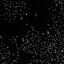

In [3]:
image_id = 37988

image_wrapper, image = ezomero.get_image(conn, image_id, dim_order='tczyx')
image_wrapper

Let's check what ROIs we find attached to this image. In our case, there are two ROIs. One for the binary mask and one for the labels image from the previous tutorial.

In [4]:
rois = image_wrapper.getROIs()
print(rois)

[<_RoiWrapper id=15695>, <_RoiWrapper id=15698>]


## Binary masks

Let's start with the first by extracting the shapes from the ROI. We can then use the `shape_to_binary_image` from [omero-rois](https://github.com/ome/omero-rois) to convert it back to an image array, in this case to a boolean array:

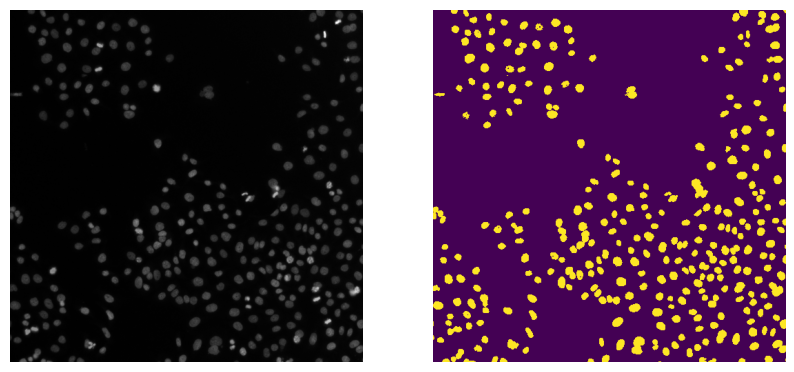

In [5]:
roi = rois[0]
shape = roi.copyShapes()[0]
array, metadata = omero_rois.shape_to_binary_image(shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image.squeeze(), cmap='gray')
axes[1].imshow(array.squeeze())

for ax in axes:
    ax.axis('off')

## Labels images

Let's do the same with the labels data that we previously attached to this data. For this, we simply iterate through all the individual masks and add them to an empty copy of the input image:

In [ ]:
roi = rois[1]
shapes = roi.copyShapes()

labels = np.zeros(image.shape, dtype=np.uint16).squeeze()
for idx, shape in enumerate(shapes):
    array, metadata = omero_rois.shape_to_binary_image(shape)
    y = metadata[3]
    x = metadata[4]
    h = metadata[5]
    w = metadata[6]

    _labels = np.zeros(image.shape, dtype=np.uint16).squeeze()
    _labels[y:y+h, x:x+w] = array
    labels += (idx + 1) * _labels

Let's see what we get from this:

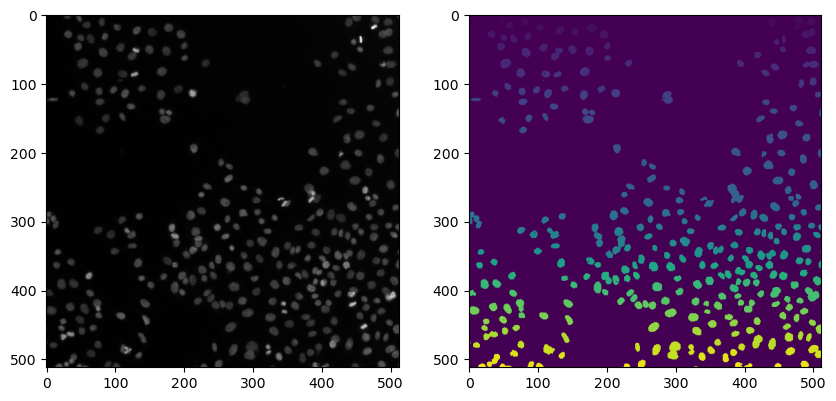

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image.squeeze(), cmap='gray')
axes[1].imshow(labels.squeeze())

In [11]:
import numpy as np
np.unique(labels)

array([    0, 15698], dtype=int64)